In [1]:
import sys
from pathlib import Path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score,precision_score,recall_score
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader,train_path,train_indices,val_indices, val_loader, ood_loader,ood_path
from src.sampler import BalancedBatchSampler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
class CNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


num_classes = len(train_data.classes)

model = CNN(num_classes)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0



for epoch in range(num_epochs):

    # =========================
    # Train
    # =========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        targets = torch.zeros(
            labels.size(0),
            num_classes,
            device=device
        )

        targets.scatter_(
            1,
            labels.unsqueeze(1),
            1
        )

        loss = criterion(outputs, targets)


        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    best_val_f1 = 0.0
    best_epoch = 0
    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            targets = torch.zeros(
                labels.size(0),
                num_classes,
                device=device
            )

            targets.scatter_(
                1,
                labels.unsqueeze(1),
                1
            )


            loss = criterion(
                outputs,
                targets
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/BCE_with_logits.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )

Epoch [1/100] | Train Loss: 0.2958 | Train Acc: 0.5031 | Val Loss: 0.1967 | Val Acc: 0.6877 | Val Precision: 0.7400 | Val Recall: 0.6344 | Val Macro F1: 0.6311
Precision by each class:
[0.59130435 0.76829268 0.58241758 0.55797101 0.81666667 0.68115942
 0.9223301  1.        ]
Recall by each class:
[0.85       0.60576923 0.55208333 0.7        0.5326087  0.84684685
 0.88785047 0.1       ]
F1 Score by each class:
[0.6974359  0.67741935 0.56684492 0.62096774 0.64473684 0.75502008
 0.9047619  0.18181818]
Best model saved! Epoch: 1 | Val Macro F1: 0.6311


Epoch [2/100] | Train Loss: 0.1499 | Train Acc: 0.7771 | Val Loss: 0.1240 | Val Acc: 0.8082 | Val Precision: 0.8112 | Val Recall: 0.7704 | Val Macro F1: 0.7799
Precision by each class:
[0.78409091 0.85714286 0.76344086 0.72881356 0.90410959 0.78740157
 0.86440678 0.8       ]
Recall by each class:
[0.8625     0.80769231 0.73958333 0.78181818 0.7173913  0.9009009
 0.95327103 0.4       ]
F1 Score by each class:
[0.82142857 0.83168317 0.75132275 0.75438596 0.8        0.84033613
 0.90666667 0.53333333]
Best model saved! Epoch: 2 | Val Macro F1: 0.7799


Epoch [3/100] | Train Loss: 0.0842 | Train Acc: 0.8921 | Val Loss: 0.1228 | Val Acc: 0.8260 | Val Precision: 0.8450 | Val Recall: 0.8060 | Val Macro F1: 0.8164
Precision by each class:
[0.94366197 0.69285714 0.87692308 0.75630252 0.78350515 0.84297521
 1.         0.86363636]
Recall by each class:
[0.8375     0.93269231 0.59375    0.81818182 0.82608696 0.91891892
 0.88785047 0.63333333]
F1 Score by each class:
[0.88741722 0.79508197 0.70807453 0.7860262  0.8042328  0.87931034
 0.94059406 0.73076923]
Best model saved! Epoch: 3 | Val Macro F1: 0.8164


Epoch [4/100] | Train Loss: 0.0430 | Train Acc: 0.9545 | Val Loss: 0.1326 | Val Acc: 0.8192 | Val Precision: 0.8126 | Val Recall: 0.8144 | Val Macro F1: 0.8064
Precision by each class:
[0.89473684 0.78512397 0.64705882 0.76635514 0.95714286 0.92553191
 0.99       0.53488372]
Recall by each class:
[0.85       0.91346154 0.80208333 0.74545455 0.72826087 0.78378378
 0.92523364 0.76666667]
F1 Score by each class:
[0.87179487 0.84444444 0.71627907 0.75576037 0.82716049 0.84878049
 0.95652174 0.63013699]


Best model saved! Epoch: 4 | Val Macro F1: 0.8064


...

Epoch [97/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.2786 | Val Acc: 0.8767 | Val Precision: 0.8766 | Val Recall: 0.8583 | Val Macro F1: 0.8654
Precision by each class:
[0.88095238 0.91346154 0.7745098  0.82407407 0.90697674 0.87179487
 0.97169811 0.86956522]
Recall by each class:
[0.925      0.91346154 0.82291667 0.80909091 0.84782609 0.91891892
 0.96261682 0.66666667]
F1 Score by each class:
[0.90243902 0.91346154 0.7979798  0.81651376 0.87640449 0.89473684
 0.96713615 0.75471698]
Best model saved! Epoch: 97 | Val Macro F1: 0.8654


Epoch [98/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.2796 | Val Acc: 0.8767 | Val Precision: 0.8766 | Val Recall: 0.8583 | Val Macro F1: 0.8654
Precision by each class:
[0.88095238 0.91346154 0.7745098  0.82407407 0.90697674 0.87179487
 0.97169811 0.86956522]
Recall by each class:
[0.925      0.91346154 0.82291667 0.80909091 0.84782609 0.91891892
 0.96261682 0.66666667]
F1 Score by each class:
[0.90243902 0.91346154 0.7979798  0.81651376 0.87640449 0.89473684
 0.96713615 0.75471698]
Best model saved! Epoch: 98 | Val Macro F1: 0.8654


Epoch [99/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.2805 | Val Acc: 0.8753 | Val Precision: 0.8755 | Val Recall: 0.8570 | Val Macro F1: 0.8642
Precision by each class:
[0.88095238 0.91346154 0.7745098  0.81651376 0.90588235 0.87179487
 0.97169811 0.86956522]
Recall by each class:
[0.925      0.91346154 0.82291667 0.80909091 0.83695652 0.91891892
 0.96261682 0.66666667]
F1 Score by each class:
[0.90243902 0.91346154 0.7979798  0.81278539 0.8700565  0.89473684
 0.96713615 0.75471698]
Best model saved! Epoch: 99 | Val Macro F1: 0.8642


Epoch [100/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.2814 | Val Acc: 0.8767 | Val Precision: 0.8766 | Val Recall: 0.8583 | Val Macro F1: 0.8654
Precision by each class:
[0.88095238 0.91346154 0.7745098  0.82407407 0.90697674 0.87179487
 0.97169811 0.86956522]
Recall by each class:
[0.925      0.91346154 0.82291667 0.80909091 0.84782609 0.91891892
 0.96261682 0.66666667]
F1 Score by each class:
[0.90243902 0.91346154 0.7979798  0.81651376 0.87640449 0.89473684
 0.96713615 0.75471698]


Best model saved! Epoch: 100 | Val Macro F1: 0.8654


In [4]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/BCE_with_logits.pth")
)

model = model.to(device)

In [5]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8767
val Macro Precision: 0.8766
val Macro Recall: 0.8583
val Macro F1: 0.8654
val Precision by class:
[0.88095238 0.91346154 0.7745098  0.82407407 0.90697674 0.87179487
 0.97169811 0.86956522]
val Recall by class:
[0.925      0.91346154 0.82291667 0.80909091 0.84782609 0.91891892
 0.96261682 0.66666667]
val F1 by class:
[0.90243902 0.91346154 0.7979798  0.81651376 0.87640449 0.89473684
 0.96713615 0.75471698]


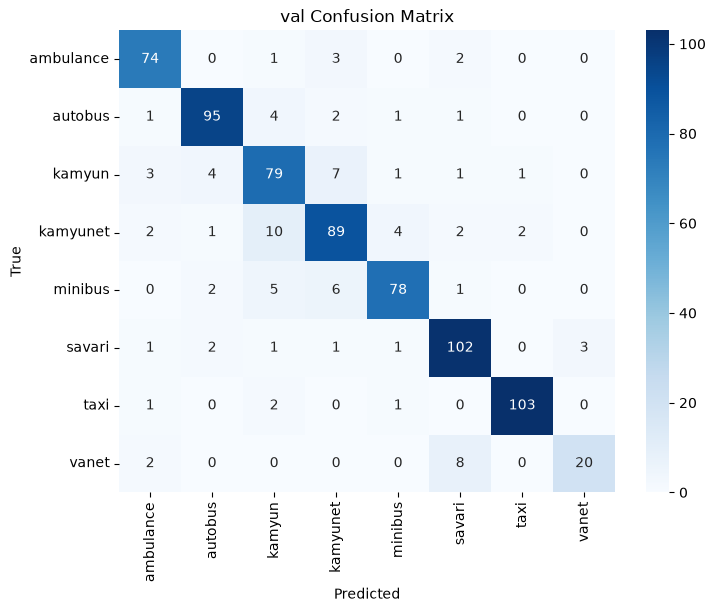

In [6]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

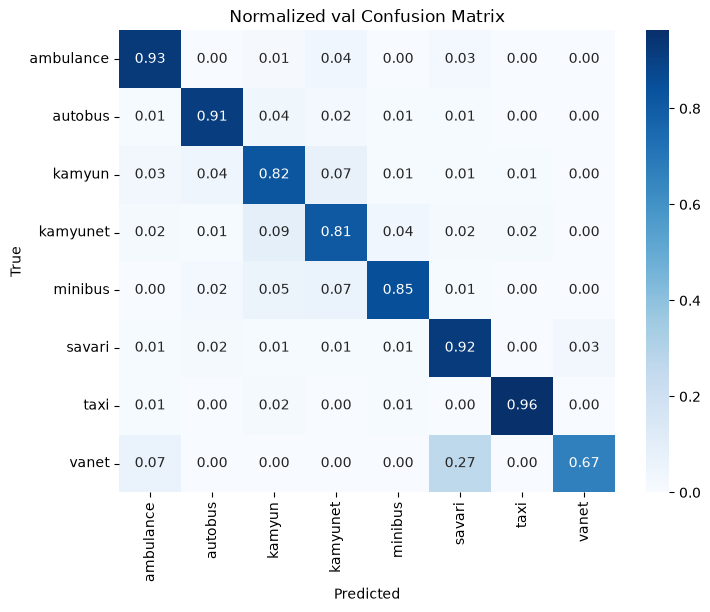

In [7]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()